# Predição de ativos da bolsa de valores

## Import Libraries

In [1]:
import sys, os
import numpy as np
import matplotlib.pyplot as plt
import plotly.express as px
from plotly.offline import plot
import plotly.graph_objects as go

import datetime
import pandas as pd
from sklearn.utils import class_weight
import utils
from glob import glob

from sklearn.preprocessing import StandardScaler, MinMaxScaler


In [2]:
import xgboost as xgb
import tensorflow as tf

from tensorflow.keras.models import Sequential, Model
from tensorflow.keras.layers import Input, Dense, Conv1D, LSTM, MaxPooling1D, Activation, MaxPooling1D, Dropout, Flatten, BatchNormalization, GRU, AveragePooling1D, SpatialDropout1D, GlobalAveragePooling1D
#from tensorflow.keras.initializers import he_uniform
from tensorflow import keras
import tensorflow_addons as tfa

d:\Projetos_python\Time_Series_Forecast\.venv\lib\site-packages\tensorflow_addons\utils\tfa_eol_msg.py:23: UserWarning:



TensorFlow Addons (TFA) has ended development and introduction of new features.
TFA has entered a minimal maintenance and release mode until a planned end of life in May 2024.
Please modify downstream libraries to take dependencies from other repositories in our TensorFlow community (e.g. Keras, Keras-CV, and Keras-NLP). 

For more information see: https://github.com/tensorflow/addons/issues/2807 


d:\Projetos_python\Time_Series_Forecast\.venv\lib\site-packages\tensorflow_addons\utils\ensure_tf_install.py:53: UserWarning:

Tensorflow Addons supports using Python ops for all Tensorflow versions above or equal to 2.12.0 and strictly below 2.15.0 (nightly versions are not supported). 
 The versions of TensorFlow you are currently using is 2.15.0 and is not supported. 
Some things might work, some things might not.
If you were to encounter a bug, do not file an issue.

In [3]:
import tensorflow as tf

print("Versão do TensorFlow:", tf.__version__)
print("GPUs disponíveis:", tf.config.list_physical_devices('GPU'))

Versão do TensorFlow: 2.15.0
GPUs disponíveis: []


In [4]:
import os, sys
processing_source_path = os.path.abspath('./../../../Processing/')
if(processing_source_path not in sys.path):
    sys.path.append(processing_source_path)
from DataLoaderPipeline import scrapingHistoricalData, FeaturesDataGenerator

import  ProcessingPipeline as pp


## Init parameters

In [5]:
# features and dataloader parameters

features_indicators=[ 'Close', 'Open', 'High', 'Low', 'Volume','Volume_log',
                    'EMA9', 'EMA20', 'EMA50', 'EMA100', 'EMA200', 'MA111', 'MA350', 
                    'RSI_14', 
                    'MACD', 'MACD_Signal', 'MACD_Histogram', 
                    'Stochastic_K', 'Stochastic_D', 
                    'Bollinger_Bands_Upper', 'Bollinger_Bands_Middle', 'Bollinger_Bands_Lower',
                    'CCI',  'ROC', 'Chaikin_Money_Flow']

#features_indicators=['SCP', 'RSI_14', 'Williams_R', 'MFI','MACD']


features_indicators=['Close', 'Open', 'High', 'Low',
                     'SCP', 'RSI_14', 'Williams_R', 'MFI','MACD',
                     'EMA9', 'EMA20', 'EMA50', 'EMA100', 'EMA200', 'MA111', 'MA350',
                     'Bollinger_Bands_Upper', 'Bollinger_Bands_Middle', 'Bollinger_Bands_Lower',
                     'CCI',  'ROC', 'Chaikin_Money_Flow']

features_indicators=['Close', 'Open', 'High', 'Low', 'Volume']

features_indicators=['Close','EMA9', 'EMA20', 'EMA50','EMA100', 'EMA200', 
                     'MA111', 'MA350',
                     'Bollinger_Bands_Upper', 'Bollinger_Bands_Middle', 'Bollinger_Bands_Lower',]

In [6]:
#pred_days = 60
#pred_days = 30
pred_days = 25
buy_sell_threshold=[0.05,-0.05]
#lookback = 20
#lookback = 60
lookback = 23# 30 # 40

batch_size = 2**4
shuffle = True
data_augmentation =False

min_norm=0
max_norm=1

trade=['Hold','Buy','Sell']

# model parameters
input_shape = (lookback, len(features_indicators))
n_classes = len(trade)



In [7]:
SHD=scrapingHistoricalData()
date_now = datetime.date.today()
cryptos_df = SHD.get_crypto_historical_data(['BTC'], '4h', '2018-01-01', date_now.strftime('%Y-%m-%d'))

cryptos_scaler = MinMaxScaler(feature_range=(min_norm, max_norm))
cryptos_scaled = cryptos_scaler.fit_transform(cryptos_df.loc[:, ['Open','High','Low','Close','Volume']].values)

output_scaler = MinMaxScaler(feature_range=(min_norm, max_norm))
output_close = output_scaler.fit_transform(cryptos_df.loc[:, ['Close']].values)


cryptos_df_scaled = pd.DataFrame(cryptos_scaled, columns=['Open','High','Low','Close','Volume'], index=cryptos_df.index)
cryptos_df_scaled.insert(0, 'Date', cryptos_df['Date'].values)

cryptos_df=cryptos_df_scaled.copy()

split_data=FeaturesDataGenerator().split_data
X_train, X_val, T_train, T_val=split_data(cryptos_df['Close'].values, cryptos_df['Date'], factor=0.80)
X_val, X_test, T_val, T_test=split_data(X_val.T, T_val, factor=0.5)

X_data_gen_train = FeaturesDataGenerator(cryptos_df[cryptos_df['Date'].isin(T_train)].iloc[:,:], datatype='1D', predict_type='classification', lookback = lookback, pred_days = pred_days, buy_sell_threshold=buy_sell_threshold, shuffle= shuffle, batch_size=batch_size, selected_features = features_indicators, data_augmentation=data_augmentation, min_max_norm_features=[min_norm, max_norm])
min_max_regression_targets= [X_data_gen_train.target_min, X_data_gen_train.target_max]

d:\Projetos_python\Time_Series_Forecast\finance\AI\Processing\MarketIndicators.py:97: RuntimeWarning:

invalid value encountered in divide

d:\Projetos_python\Time_Series_Forecast\finance\AI\Processing\DataLoaderPipeline.py:694: RuntimeWarning:

divide by zero encountered in log



input data shape (19, 1, 30)
output data shape (19, 3)


d:\Projetos_python\Time_Series_Forecast\finance\AI\Processing\DataLoaderPipeline.py:290: RuntimeWarning:

divide by zero encountered in scalar divide

d:\Projetos_python\Time_Series_Forecast\finance\AI\Processing\MarketIndicators.py:340: RuntimeWarning:

divide by zero encountered in scalar divide



input data shape (11977, 23, 11)
output data shape (11977, 3)


In [8]:
min_max_regression_targets

[0.0, 0.60140574]

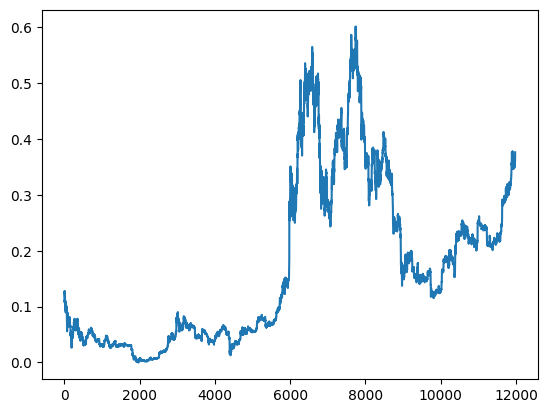

In [9]:
min_max_regression_targets
plt.plot(X_data_gen_train.y_regression)
plt.show()

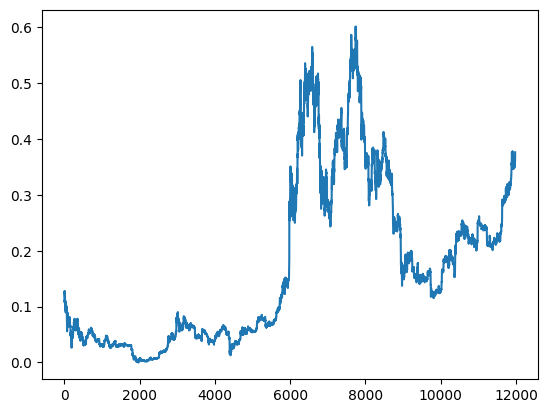

In [10]:
plt.plot(X_data_gen_train.features[:,-1,0])
plt.show()

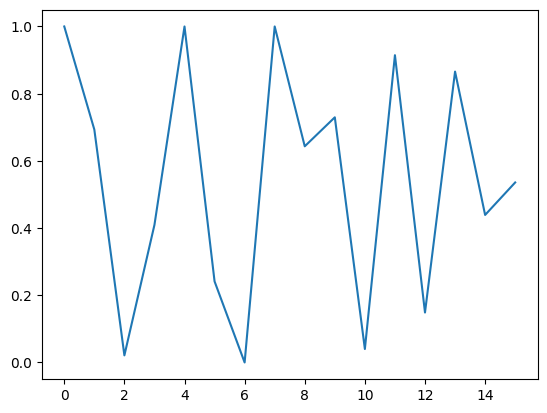

In [11]:
plt.plot(X_data_gen_train[3][0][:,-1,0])
plt.show()

In [12]:
Y_train_categorical=np.argmax(X_data_gen_train.y_classification,axis=1)

n_classes, counts=np.unique(Y_train_categorical, return_counts=True) 
print(n_classes, counts)
output_class_weights = class_weight.compute_class_weight('balanced', classes=n_classes, y=np.argmax(X_data_gen_train.y_classification,axis=1))

print(output_class_weights)

# Formula used - Naive method where
# weight = 1 - (no. of samples present / total no. of samples)
# So more the samples, lower the weight

weight_dict = {k: (1 - (v / counts.sum())) for k, v in enumerate(counts)}
print(weight_dict)


[0 1 2] [11061   459   457]
[0.36093783 8.69789397 8.73595915]
{0: 0.07647991984637226, 1: 0.9616765467145362, 2: 0.9618435334390916}


## Deep Learning Model

In [13]:
import tensorflow as tf
from tensorflow.keras.layers import (
    Input, Conv1D, BatchNormalization, Activation, MaxPooling1D, Dropout, Dense, Flatten
)
from tensorflow.keras.models import Model
from tensorflow.keras.regularizers import l2

In [14]:
from tensorflow.keras.layers import Reshape, GlobalAveragePooling2D


# Camadas comuns em 1D
def common_layers(input_layer, dropout_rate):
    x = Conv1D(64, 3, padding="same")(input_layer)
    #x = BatchNormalization()(x)
    x = Activation('relu')(x)
    x = MaxPooling1D(pool_size=3, strides=1, padding="same")(x)
    x = Dropout(dropout_rate)(x)

    x = Conv1D(128, 3, padding="same")(x)
    #x = BatchNormalization()(x)
    x = Activation('relu')(x)
    x = MaxPooling1D(pool_size=3, strides=2, padding="same")(x)
    x = Dropout(dropout_rate)(x)

    return x

# Camada head em 1D
def head_layer(conv_layer, num_classes, dropout_rate, l2_regularization, activation='linear', output_name=None):
    x = Conv1D(256, 3, padding="same")(conv_layer)
    #x = BatchNormalization()(x)
    x = Activation('relu')(x)
    x = MaxPooling1D(pool_size=3, strides=2, padding="same")(x)
    x = Dropout(dropout_rate)(x)

    x = Flatten()(x)
    x = Dense(256, kernel_regularizer=l2(l2_regularization))(x)
    #x = BatchNormalization()(x)
    x = Activation('relu')(x)
    x = Dropout(dropout_rate)(x)

    x = Dense(128, kernel_regularizer=l2(l2_regularization))(x)
    #x = BatchNormalization()(x)
    x = Activation('relu')(x)
    x = Dropout(dropout_rate)(x)

    x = Dense(num_classes)(x)
    x = Activation(activation, name=output_name)(x)

    return x

# Criando o modelo completo
def create_model_1D(input_shape, num_classes, dropout_rate=0.2, l2_regularization=0.01):
    input_layer = Input(shape=input_shape)

    features = common_layers(input_layer, dropout_rate)

    regression_output = head_layer(
        features, 
        num_classes=1, 
        dropout_rate=dropout_rate, 
        l2_regularization=l2_regularization, 
        activation='linear', 
        output_name='segmentation_head'
    )

    model = Model(inputs=input_layer, outputs=[regression_output], name="CNN_forecast_MultiHead_1D")
    return model

# Definindo parâmetros
input_shape_model = (input_shape[0],input_shape[1])  

num_classes = 3
dropout_rate = 0.3
l2_regularization = 0.01

# Criando o modelo
model_CNN_MultiHead = create_model_1D(input_shape_model, num_classes, dropout_rate, l2_regularization)

# Resumo do modelo
model_CNN_MultiHead.summary()
list_of_models = [model_CNN_MultiHead]



Model: "CNN_forecast_MultiHead_1D"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 input_1 (InputLayer)        [(None, 23, 11)]          0         
                                                                 
 conv1d (Conv1D)             (None, 23, 64)            2176      
                                                                 
 activation (Activation)     (None, 23, 64)            0         
                                                                 
 max_pooling1d (MaxPooling1  (None, 23, 64)            0         
 D)                                                              
                                                                 
 dropout (Dropout)           (None, 23, 64)            0         
                                                                 
 conv1d_1 (Conv1D)           (None, 23, 128)           24704     
                                       

In [15]:
#Metrics and Loss Functions  

from tensorflow.keras import backend as K

def matthews_correlation_coefficient(y_true, y_pred):
    tp = K.sum(K.round(K.clip(y_true * y_pred, 0, 1)))
    tn = K.sum(K.round(K.clip((1 - y_true) * (1 - y_pred), 0, 1)))
    fp = K.sum(K.round(K.clip((1 - y_true) * y_pred, 0, 1)))
    fn = K.sum(K.round(K.clip(y_true * (1 - y_pred), 0, 1)))

    num = tp * tn - fp * fn
    den = (tp + fp) * (tp + fn) * (tn + fp) * (tn + fn)
    return num / K.sqrt(den + K.epsilon())

def R2(y_true, y_pred): # squareds Pearson's correlation coef 
    SS_res =  K.sum(K.square( y_true-y_pred ))
    SS_tot = K.sum(K.square( y_true - K.mean(y_true) ) )
    return ( 1 - SS_res/(SS_tot - K.epsilon()) )

def NRMSE(y_true, y_pred): # normalized_root_mean_squared_error
    return 1-K.sqrt(K.mean(K.square(y_pred - y_true))) 

MSE= tf.keras.losses.mean_squared_error
MAE = tf.keras.losses.mean_absolute_error
MAPE = tf.keras.losses.mean_absolute_percentage_error

In [16]:
#Optimizers
def get_optimizer():
    optimizer1 = tf.keras.optimizers.Adam(learning_rate=0.01, beta_1=0.9, beta_2=0.999, epsilon=1e-08, amsgrad=True, name="Adam")
    #optimizer1 = tf.keras.optimizers.RMSprop(learning_rate=0.001)
    #optimizer = optimizers.SGD(lr=params["lr"], decay=1e-6, momentum=0.9, nesterov=True)

    return optimizer1
    #

#Train options callbacks
    # Avalia se está tendo avanção de desempenho no treinamento/validação e para caso não tenha avanço 
EarlyStopping=tf.keras.callbacks.EarlyStopping( monitor="val_loss", patience=20, verbose=1, mode="min", restore_best_weights=True,)

    # verifica se está tendo avanço de desempenho durante o treinamento, caso não reduz integralmente o lr
reduceLr = tf.keras.callbacks.ReduceLROnPlateau(monitor='val_loss', factor = 0.01, patience = 5, min_lr=1e-20,verbose=1)



def checkpoints(model_name, cryptos):
    checkpoint_filepath =f'models/model_{model_name}_crypto_{cryptos}'
    csvLogger = tf.keras.callbacks.CSVLogger(checkpoint_filepath+'_history.csv', separator=',',append=True)
    model_checkpoint_callback = tf.keras.callbacks.ModelCheckpoint(filepath=checkpoint_filepath, verbose=1, save_weights_only=False, monitor='val_loss', mode='min', save_best_only=True)
    print("Training model :", checkpoint_filepath)

    return csvLogger, model_checkpoint_callback

model_name = 'CNN_forecast_MultiHead_1D'

In [17]:
model_name

'CNN_forecast_MultiHead_1D'

In [18]:
list_of_models=[model_CNN_MultiHead]

## Load Data And train

In [19]:
SHD=scrapingHistoricalData()

# Lista de criptomoedas
interval = '4h'#


In [20]:
import datetime
init_date = '2017-01-01'
#init_date = '2020-01-01'
init_date_object = datetime.datetime.strptime(init_date, '%Y-%m-%d').date()

date_now = datetime.date.today()

diff_years = date_now.year - init_date_object.year
year_window = 8


cryptos_list = [ 'BTC','ETH','SOL','XRP','ADA','DOT'] 
cryptos_list = ['BTC']

if year_window > diff_years:
    raise ValueError("O intervalo de anos (year_window) é maior do que o período disponível nos dados.")


In [21]:
X_data_gen_train[0][0][0,:].shape

TensorShape([23, 11])

BTC Dataset Period:2017-01-01 : 2025-06-24
The file ./../../../Data_history\BTC_4h_2017-08-17_2025-04-23.csv exist in folder path.
input data shape (19, 1, 30)
output data shape (19, 3)
Train data shape (12402,)
Vall data shape (1551,)
Test data shape (1552,)


d:\Projetos_python\Time_Series_Forecast\finance\AI\Processing\MarketIndicators.py:97: RuntimeWarning:

invalid value encountered in divide

d:\Projetos_python\Time_Series_Forecast\finance\AI\Processing\DataLoaderPipeline.py:694: RuntimeWarning:

divide by zero encountered in log

d:\Projetos_python\Time_Series_Forecast\finance\AI\Processing\DataLoaderPipeline.py:290: RuntimeWarning:

divide by zero encountered in scalar divide

d:\Projetos_python\Time_Series_Forecast\finance\AI\Processing\MarketIndicators.py:340: RuntimeWarning:

divide by zero encountered in scalar divide



input data shape (12379, 23, 11)
output data shape (12379, 3)
input data shape (1528, 23, 11)
output data shape (1528, 3)
input data shape (1529, 23, 11)
output data shape (1529, 3)
[0 1 2] [11431   476   472]
Training model : models/model_CNN_forecast_MultiHead_1D_crypto_BTC
------------------------------------------------------------------------------------------------------------------------------------------------------------------------
Initing train for model: CNN_forecast_MultiHead_1D
Epoch 1/200


772/773 [============================>.] - ETA: 0s - loss: 0.2177 - NRMSE: 0.9231 - mean_absolute_error: 0.0563 - mean_absolute_percentage_error: 3239694.0000
Epoch 1: val_loss improved from inf to 0.03503, saving model to models\model_CNN_forecast_MultiHead_1D_crypto_BTC
INFO:tensorflow:Assets written to: models\model_CNN_forecast_MultiHead_1D_crypto_BTC\assets


INFO:tensorflow:Assets written to: models\model_CNN_forecast_MultiHead_1D_crypto_BTC\assets


773/773 [==============================] - 42s 47ms/step - loss: 0.2174 - NRMSE: 0.9232 - mean_absolute_error: 0.0563 - mean_absolute_percentage_error: 3235502.7500 - val_loss: 0.0350 - val_NRMSE: 0.8254 - val_mean_absolute_error: 0.1576 - val_mean_absolute_percentage_error: 3850090.0000 - lr: 0.0100
Epoch 2/200
772/773 [============================>.] - ETA: 0s - loss: 0.0085 - NRMSE: 0.9285 - mean_absolute_error: 0.0555 - mean_absolute_percentage_error: 3660128.7500
Epoch 2: val_loss improved from 0.03503 to 0.02833, saving model to models\model_CNN_forecast_MultiHead_1D_crypto_BTC
INFO:tensorflow:Assets written to: models\model_CNN_forecast_MultiHead_1D_crypto_BTC\assets


...

773/773 [==============================] - 29s 37ms/step - loss: 0.0080 - NRMSE: 0.9280 - mean_absolute_error: 0.0572 - mean_absolute_percentage_error: 3735926.2500 - val_loss: 0.0273 - val_NRMSE: 0.8436 - val_mean_absolute_error: 0.1358 - val_mean_absolute_percentage_error: 4156355.7500 - lr: 0.0100
Epoch 4/200
771/773 [============================>.] - ETA: 0s - loss: 0.0087 - NRMSE: 0.9271 - mean_absolute_error: 0.0580 - mean_absolute_percentage_error: 4131251.7500
Epoch 4: val_loss did not improve from 0.02730
773/773 [==============================] - 26s 33ms/step - loss: 0.0087 - NRMSE: 0.9272 - mean_absolute_error: 0.0580 - mean_absolute_percentage_error: 4120562.7500 - val_loss: 0.0352 - val_NRMSE: 0.8353 - val_mean_absolute_error: 0.1456 - val_mean_absolute_percentage_error: 1254484.6250 - lr: 0.0100
Epoch 5/200
772/773 [============================>.] - ETA: 0s - loss: 0.0078 - NRMSE: 0.9301 - mean_absolute_error: 0.0557 - mean_absolute_percentage_error: 3851393.7500
Epoch 5

INFO:tensorflow:Assets written to: models\model_CNN_forecast_MultiHead_1D_crypto_BTC\assets


773/773 [==============================] - 40s 51ms/step - loss: 0.0078 - NRMSE: 0.9301 - mean_absolute_error: 0.0557 - mean_absolute_percentage_error: 3846411.5000 - val_loss: 0.0244 - val_NRMSE: 0.8526 - val_mean_absolute_error: 0.1305 - val_mean_absolute_percentage_error: 2386150.2500 - lr: 0.0100
Epoch 6/200
772/773 [============================>.] - ETA: 0s - loss: 0.0078 - NRMSE: 0.9289 - mean_absolute_error: 0.0565 - mean_absolute_percentage_error: 3820781.7500
Epoch 6: val_loss did not improve from 0.02441
773/773 [==============================] - 23s 29ms/step - loss: 0.0078 - NRMSE: 0.9289 - mean_absolute_error: 0.0565 - mean_absolute_percentage_error: 3815839.0000 - val_loss: 0.0328 - val_NRMSE: 0.8408 - val_mean_absolute_error: 0.1461 - val_mean_absolute_percentage_error: 2943600.2500 - lr: 0.0100
Epoch 7/200
772/773 [============================>.] - ETA: 0s - loss: 0.0072 - NRMSE: 0.9305 - mean_absolute_error: 0.0556 - mean_absolute_percentage_error: 3775571.2500
Epoch 7

INFO:tensorflow:Assets written to: models\model_CNN_forecast_MultiHead_1D_crypto_BTC\assets


773/773 [==============================] - 30s 39ms/step - loss: 0.0078 - NRMSE: 0.9266 - mean_absolute_error: 0.0591 - mean_absolute_percentage_error: 4140524.2500 - val_loss: 0.0236 - val_NRMSE: 0.8558 - val_mean_absolute_error: 0.1205 - val_mean_absolute_percentage_error: 3499917.7500 - lr: 1.0000e-04
Epoch 12/200
773/773 [==============================] - ETA: 0s - loss: 0.0070 - NRMSE: 0.9284 - mean_absolute_error: 0.0574 - mean_absolute_percentage_error: 3820444.0000
Epoch 12: val_loss did not improve from 0.02356
773/773 [==============================] - 18s 23ms/step - loss: 0.0070 - NRMSE: 0.9284 - mean_absolute_error: 0.0574 - mean_absolute_percentage_error: 3820444.0000 - val_loss: 0.0239 - val_NRMSE: 0.8534 - val_mean_absolute_error: 0.1214 - val_mean_absolute_percentage_error: 3579448.2500 - lr: 1.0000e-04
Epoch 13/200
772/773 [============================>.] - ETA: 0s - loss: 0.0066 - NRMSE: 0.9297 - mean_absolute_error: 0.0558 - mean_absolute_percentage_error: 3858520.0

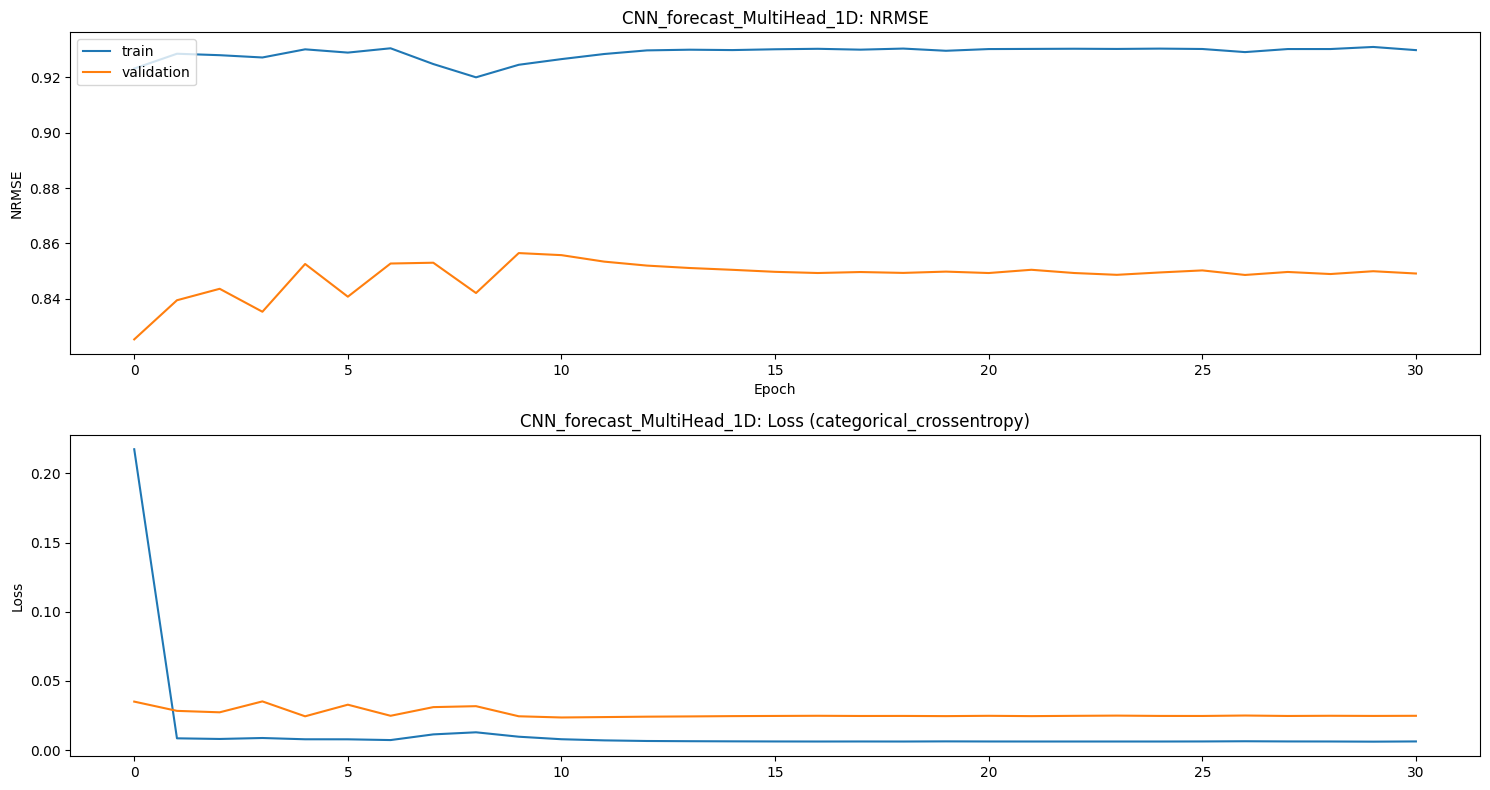

---------------------------------------------------------------------------------------------------------------------------------
CNN_forecast_MultiHead_1D



Model name: CNN_forecast_MultiHead_1D


In [22]:
idx=0
for i, cryptos in enumerate(cryptos_list):

    for stride_year in range(0, diff_years-year_window+1):
        init_time=f'{init_date_object.year+stride_year}-01-01'

        look_year=init_date_object.year+stride_year+year_window
        if date_now.year == look_year:
            end_time=date_now.strftime('%Y-%m-%d')
        else:
            end_time=f'{look_year}-01-01'
        print(f'{cryptos} Dataset Period:{init_time} : {end_time}') 

        # Caminho do arquivo
        #file_folder = f'Data_history/{cryptos_list[0]}_{interval}_{init_time}_{end_time}.csv'
        try:
            file_folder = [crypto_data for crypto_data in glob("./../../../Data_history/*")  if cryptos in crypto_data][0]
        except:
            file_folder =""
            
        if os.path.exists(file_folder):
            print(f"The file {file_folder} exist in folder path.")
            cryptos_df=pd.read_csv(file_folder, index_col=0)

            #mask = (cryptos_df['Date'] >= init_time) & (cryptos_df['Date'] <= end_time)
            #cryptos_df = cryptos_df[mask]
            
            #cryptos_df.reset_index(drop=True, inplace=True)
            #cryptos_df.to_csv(file_folder)
            #print(f"Save the file {file_folder} in folder path.")
        else:
            print(f"Donwload the file {file_folder} from bincance history.")
            # Obtenha os dados históricos
            cryptos_df = SHD.get_crypto_historical_data([cryptos], interval, init_time, end_time)



        #----------------------------------------------------------------------------------------------------------------------------------
        cryptos_scaler = MinMaxScaler(feature_range=(min_norm, max_norm))
        cryptos_scaled = cryptos_scaler.fit_transform(cryptos_df.loc[:, ['Open','High','Low','Close','Volume']].values)

        output_scaler = MinMaxScaler(feature_range=(min_norm, max_norm))
        output_close = output_scaler.fit_transform(cryptos_df.loc[:, ['Close']].values)


        cryptos_df_scaled = pd.DataFrame(cryptos_scaled, columns=['Open','High','Low','Close','Volume'], index=cryptos_df.index)
        cryptos_df_scaled.insert(0, 'Date', cryptos_df['Date'].values)
        # ----------------------------------------------------------------------------------------------------------------------------------    
        
        # split the data in train validation and test
        split_data=FeaturesDataGenerator().split_data
        X_train, X_val, T_train, T_val=split_data(cryptos_df['Close'].values, cryptos_df['Date'], factor=0.80)
        X_val, X_test, T_val, T_test=split_data(X_val.T, T_val, factor=0.5)

        print('Train data shape',X_train.shape)
        print('Vall data shape',X_val.shape)
        print('Test data shape',X_test.shape)

        #TODO: mot used more 
        # get train vall and test dataloader
        regression_targets = [cryptos_df['Close'].min(), cryptos_df['Close'].max()]

        X_data_gen_train = FeaturesDataGenerator(cryptos_df_scaled[cryptos_df_scaled['Date'].isin(T_train)].iloc[:,:], datatype='1D', predict_type='regression', lookback = lookback, pred_days = pred_days, buy_sell_threshold=buy_sell_threshold, shuffle= shuffle, batch_size=batch_size, selected_features = features_indicators, data_augmentation=data_augmentation, min_max_norm_features=[min_norm, max_norm], min_max_regression_targets=regression_targets)
        X_data_gen_val = FeaturesDataGenerator(cryptos_df_scaled[cryptos_df_scaled['Date'].isin(T_val)].iloc[:,:], datatype='1D', predict_type='regression', lookback = lookback, pred_days = pred_days,  buy_sell_threshold=buy_sell_threshold, shuffle= shuffle, batch_size=batch_size, selected_features = features_indicators, data_augmentation=data_augmentation, min_max_norm_features=[min_norm, max_norm], min_max_regression_targets=regression_targets)
        X_data_gen_test = FeaturesDataGenerator(cryptos_df_scaled[cryptos_df_scaled['Date'].isin(T_test)].iloc[:,:], datatype='1D', predict_type='regression', lookback = lookback, pred_days = pred_days,  buy_sell_threshold=buy_sell_threshold, shuffle= False, batch_size=batch_size, selected_features = features_indicators, data_augmentation=False, min_max_norm_features=[min_norm, max_norm], min_max_regression_targets= regression_targets)

        # get classes weigths 
        Y_train_categorical=np.argmax(X_data_gen_train.y_classification,axis=1)
        n_classes, counts=np.unique(Y_train_categorical, return_counts=True) 
        print(n_classes, counts)       
       
        loss = MSE
        
        for idx_model, model in enumerate(list_of_models):

            if idx == 0:  
                optimizer = get_optimizer()
                csvLogger, model_checkpoint_callback  = checkpoints(model._name, cryptos)
                model.compile(loss=[loss], optimizer=optimizer, metrics=[NRMSE, MAE, MAPE])
                idx=1
            else:
                optimizer = get_optimizer()
                csvLogger, model_checkpoint_callback  = checkpoints(model._name, cryptos)
                model = trained_best_models[model._name]
                model.compile(loss=[loss], optimizer=optimizer, metrics=[NRMSE, MAE, MAPE])




            print('------------------------------------------------------------------------------------------------------------------------------------------------------------------------')
            print(f'Initing train for model: {model._name}')

            history = model.fit(
                X_data_gen_train,
                epochs=200,
                callbacks=[EarlyStopping, reduceLr, model_checkpoint_callback, csvLogger],
                validation_data=X_data_gen_val,
                #shuffle=True,
                #class_weight=weight_dict,
                #class_weight=dict(enumerate([1, 1, 1])),
                verbose=1
            )
            # Assuming history_metric, history_metric_val, history are defined elsewhere

            fig, axes = plt.subplots(2, 1, figsize=(15, 8))  # Create subplots programmatically

            # Plot accuracy, sharing x-axis with NRMSE
            axes[0].plot(history.history['NRMSE'])
            axes[0].plot(history.history['val_NRMSE'])
            axes[0].set_title(f'{model._name}: NRMSE')
            axes[0].set_ylabel('NRMSE')
            axes[0].set_xlabel('Epoch')  # Shared x-axis label
            axes[0].legend(['train', 'validation'], loc='upper left')

            # Plot loss
            axes[1].plot(history.history['loss'])
            axes[1].plot(history.history['val_loss'])
            axes[1].set_title(f'{model._name}: Loss (categorical_crossentropy)')
            axes[1].set_ylabel('Loss')

            # Adjust spacing and margins (optional)
            plt.subplots_adjust(left=0.1, bottom=0.15, right=0.9, top=0.9, wspace=0.2)

            # Fine-tune spacing (optional)
            plt.tight_layout()

            plt.show()

        trained_best_models={}
        print("---------------------------------------------------------------------------------------------------------------------------------")
        for model in list_of_models:
            print(model.name)
            checkpoint_filepath =f'models/model_{model._name}_crypto_{cryptos}'
            trained_best_models[f'{model._name}']=tf.keras.models.load_model(
                checkpoint_filepath, 
                custom_objects={'loss': MSE, 'NRMSE': NRMSE}, 
                compile=False)

            print('Model name:',model_name)

            #x_data=X_data_gen_test.apply_NomrMinmax(X_data_gen_test.features, min_norm, max_norm, axis=0)
            #x_data = np.transpose(x_data, [0, 2, 1]).reshape(-1, 1, input_shape[1], input_shape[0])
            
            #label_pred = trained_best_models[model_name].predict(x_data)
            #print(model_name,' Regression NRMSE',
            #                utils.f1_score(np.argmax(X_data_gen_test.y_classification,axis=1),
            #                np.argmax(label_pred,axis=1),average="micro"))

            #cf_matrix = utils.confusion_matrix(np.argmax(X_data_gen_test.y_classification,axis=1),np.argmax(label_pred,axis=1))
            #try:
            #    utils.plot_confusion_matrix(gesture_list= ['Hold','Buy','Sell'], cf_matrix=cf_matrix)
            #except:
            #    print(cf_matrix)


In [23]:
[crypto_data for crypto_data in  glob("./../../../Data_history/*")]

['./../../../Data_history\\ADA_4h_2018-04-17_2025-04-23.csv',
 './../../../Data_history\\BNB_4h_2017-11-06_2025-05-11.csv',
 './../../../Data_history\\BTC_4h_2017-08-17_2025-04-23.csv',
 './../../../Data_history\\DOT_4h_2020-08-18_2025-04-23.csv',
 './../../../Data_history\\ENA_4h_2024-04-02_2025-02-27.csv',
 './../../../Data_history\\ENA_4h_2024-04-02_2025-05-11.csv',
 './../../../Data_history\\ETH_4h_2017-08-17_2025-04-23.csv',
 './../../../Data_history\\FET_4h_2019-02-28_2025-02-27.csv',
 './../../../Data_history\\FET_4h_2019-02-28_2025-05-11.csv',
 './../../../Data_history\\INJ_4h_2020-10-21_2025-05-11.csv',
 './../../../Data_history\\NEAR_4h_2020-10-14_2025-05-11.csv',
 './../../../Data_history\\RAY_4h_2021-08-10_2025-02-27.csv',
 './../../../Data_history\\SNX_4h_2020-07-09_2025-05-11.csv',
 './../../../Data_history\\SOL_4h_2020-08-11_2025-04-23.csv',
 './../../../Data_history\\TRX_4h_2018-06-11_2025-05-11.csv',
 './../../../Data_history\\XLM_4h_2018-05-31_2025-05-11.csv',
 './../

In [24]:
file_folder = [crypto_data for crypto_data in glob("./../../../Data_history/*")  if cryptos in crypto_data][0]

In [25]:
checkpoint_filepath

'models/model_CNN_forecast_MultiHead_1D_crypto_BTC'

In [26]:
output_class_weights

array([0.36093783, 8.69789397, 8.73595915])

### Save the model parameters to inference

In [27]:
import json
model_data_parameters = {
    'symbol':cryptos_list,
    'model_name':model_name,
    'features_indicators': features_indicators,
    'pred_days': pred_days,
    'buy_sell_threshold': buy_sell_threshold,
    'lookback': lookback,
    'batch_size': batch_size,
    'shuffle': shuffle,
    'data_augmentation': data_augmentation,
    'min_norm': min_norm,
    'max_norm': max_norm,
    'trade': trade,
}

# Salve os dados em um arquivo JSON
with open(f'{checkpoint_filepath}/config.json', 'w') as file:
    json.dump(model_data_parameters, file, indent=4)

### Load the best trained model

In [28]:
trained_best_models={}
print("---------------------------------------------------------------------------------------------------------------------------------")
for model in list_of_models:
    print(model.name)
    checkpoint_filepath =f'models/model_{model._name}_crypto_{cryptos}'
    trained_best_models[f'{model._name}']=tf.keras.models.load_model(
        checkpoint_filepath, 
        custom_objects={'loss': MSE, 'NRMSE': NRMSE}, 
        compile=False)

    print('Model name:',model_name)

---------------------------------------------------------------------------------------------------------------------------------
CNN_forecast_MultiHead_1D
Model name: CNN_forecast_MultiHead_1D


### Vall Data 

**vallidation metric**

In [29]:
def R2(y_true, y_pred): # squareds Pearson's correlation coef 
    SS_res =  np.sum(np.square( y_true-y_pred ))
    SS_tot = np.sum(np.square( y_true - np.mean(y_true) ) )
    return ( 1 - SS_res/(SS_tot) )

In [30]:
X_data_gen_val.features.shape

(1528, 23, 11)

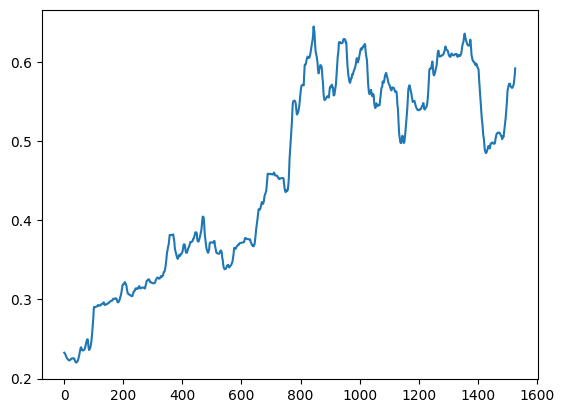

In [31]:
plt.plot(X_data_gen_val.features[:,-1,-1])
plt.show()

In [32]:
#X_data_gen_train = FeaturesDataGenerator(cryptos_df_scaled[cryptos_df_scaled['Date'].isin(T_train)].iloc[:,:], datatype='1D', predict_type='regression', lookback = lookback, pred_days = pred_days, buy_sell_threshold=buy_sell_threshold, shuffle= shuffle, batch_size=batch_size, selected_features = features_indicators, data_augmentation=data_augmentation, min_max_norm_features=[min_norm, max_norm], min_max_regression_targets=regression_targets)
#X_data_gen_val = FeaturesDataGenerator(cryptos_df_scaled[cryptos_df_scaled['Date'].isin(T_val)].iloc[:,:], datatype='1D', predict_type='regression', lookback = lookback, pred_days = pred_days,  buy_sell_threshold=buy_sell_threshold, shuffle= shuffle, batch_size=batch_size, selected_features = features_indicators, data_augmentation=data_augmentation, min_max_norm_features=[min_norm, max_norm], min_max_regression_targets=regression_targets)
#X_data_gen_test = FeaturesDataGenerator(cryptos_df_scaled[cryptos_df_scaled['Date'].isin(T_test)].iloc[:,:], datatype='1D', predict_type='regression', lookback = lookback, pred_days = pred_days,  buy_sell_threshold=buy_sell_threshold, shuffle= False, batch_size=batch_size, selected_features = features_indicators, data_augmentation=False, min_max_norm_features=[min_norm, max_norm], min_max_regression_targets= regression_targets)


In [33]:
cryptos_df_scaled[cryptos_df_scaled['Date'].isin(T_val)].iloc[:,:]

,Date,Open,High,Low,Close,Volume
12401,2023-10-06 12:00:00,0.236211,0.233905,0.233600,0.237581,0.051189
12402,2023-10-06 16:00:00,0.237929,0.233841,0.239480,0.237688,0.024833
12403,2023-10-06 20:00:00,0.238036,0.236255,0.240329,0.237486,0.017270
12404,2023-10-07 00:00:00,0.237834,0.233069,0.239988,0.237195,0.009776
12405,2023-10-07 04:00:00,0.237543,0.232965,0.240304,0.237104,0.006128
...,...,...,...,...,...,...
13947,2024-07-21 20:00:00,0.612624,0.612727,0.618143,0.619505,0.017472
13948,2024-07-22 00:00:00,0.619678,0.613741,0.622737,0.616795,0.010293
13949,2024-07-22 04:00:00,0.616970,0.609245,0.616681,0.610681,0.010364
13950,2024-07-22 08:00:00,0.610858,0.605515,0.614973,0.613339,0.008680


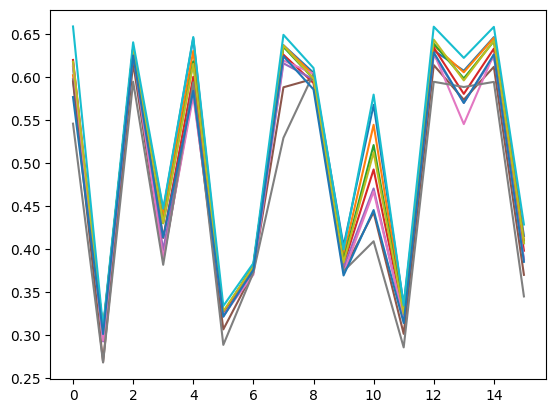

In [34]:
plt.plot(X_data_gen_val[1][0][:,-1,:])
plt.show()

In [35]:
train_label_pred = trained_best_models[model_name].predict(X_data_gen_train.features)

print(' R2', R2(X_data_gen_train.y_regression, train_label_pred))
print(' NRMSE', NRMSE(X_data_gen_train.y_regression, train_label_pred))

387/387 [==============================] - 4s 7ms/step
 R2 0.8973454236984253
 NRMSE tf.Tensor(0.9511502, shape=(), dtype=float32)


In [36]:
print('Model name:',model_name)

#x_data=X_data_gen_val.apply_NomrMinmax(X_data_gen_val.features, min_norm,  max_norm, axis=0)

val_label_pred = trained_best_models[model_name].predict(X_data_gen_val.features)

print(' R2', R2(X_data_gen_val.y_regression, val_label_pred))
print(' NRMSE', NRMSE(X_data_gen_val.y_regression, val_label_pred))

Model name: CNN_forecast_MultiHead_1D


48/48 [==============================] - 1s 7ms/step
 R2 -0.3551595211029053
 NRMSE tf.Tensor(0.8483339, shape=(), dtype=float32)


In [37]:
test_label_pred = trained_best_models[model_name].predict(X_data_gen_test.features)

print(' R2', R2(X_data_gen_test.y_regression, test_label_pred))
print(' NRMSE', NRMSE(X_data_gen_test.y_regression, test_label_pred))

48/48 [==============================] - 0s 6ms/step
 R2 -5.141090393066406
 NRMSE tf.Tensor(0.62709177, shape=(), dtype=float32)


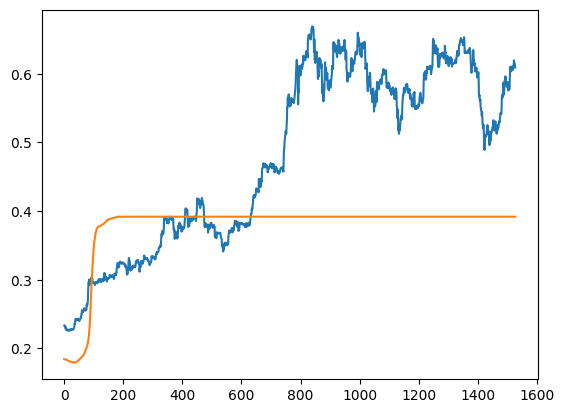

In [38]:
plt.plot(X_data_gen_val.y_regression)
plt.plot(val_label_pred)

plt.show()

In [39]:
T_train=pd.to_datetime(T_train)
T_val=pd.to_datetime(T_val)
T_test=pd.to_datetime(T_test)

In [40]:
val_label_pred.shape

(1528, 1)

In [41]:
import plotly.graph_objects as go

# Cria um gráfico de linha usando o Plotly
fig = go.Figure()

# Adiciona os valores reais ao gráfico
#fig.add_trace(go.Scatter(x=T_test, y=y_test_real, mode='lines', name='Real', line=dict(color='red')))
fig.add_trace(go.Scatter(x=T_train[lookback:], y=X_data_gen_train.y_regression[:,0], mode='lines',name="Dados de Treino",line=dict(color='black')))
fig.add_trace(go.Scatter(x=T_val[lookback:], y=X_data_gen_val.y_regression[:,0], mode='lines', name="Dados de Validação", line=dict(color='red')))
fig.add_trace(go.Scatter(x=T_test[lookback:], y=X_data_gen_test.y_regression[:,0], mode='lines', name="Dados de Teste", line=dict(color='orange')))

fig.add_trace(go.Scatter(x=T_train[lookback:], y=train_label_pred[:,0], mode='lines', name="Dados preditos de Validação", line=dict(color='lightblue')))
fig.add_trace(go.Scatter(x=T_val[lookback:], y=val_label_pred[:,0], mode='lines', name="Dados preditos de Validação", line=dict(color='blue')))
fig.add_trace(go.Scatter(x=T_test[lookback:], y=test_label_pred[:,0], mode='lines', name="Dados preditos de test", line=dict(color='darkblue')))

## Adiciona os valores preditos ao gráfico
#colors=['blue', 'yellow', 'violet', 'yellowgreen', 'green']
#for i in range(predictions.shape[1]):
#    fig.add_trace(go.Scatter(x=T_test, y=predictions[:,i], mode='lines', name=f'{list(trained_best_models.keys())[i]}', line=dict(color=colors[i])))

# Configura o layout do gráfico
fig.update_layout(
    title=f'Resultado da predição com o modelo {model_name}',
    xaxis_title='Data',
    yaxis_title='Valor',
    showlegend=True,
    legend=dict(x=0, y=1, bgcolor='rgba(255, 255, 255, 0.5)')
)

# Exibe o gráfico
fig.show()

In [42]:
X_data_gen_train.features.shape

(12379, 23, 11)

In [43]:
X_data_gen_train.features[:,-1,:]

array([[0.01106872, 0.01132299, 0.01183491, ..., 0.01160984, 0.01354419,
        0.00967549],
       [0.0106782 , 0.01119403, 0.01172474, ..., 0.01149521, 0.01336399,
        0.00962643],
       [0.01048337, 0.0110519 , 0.01160652, ..., 0.01136737, 0.01314343,
        0.00959132],
       ...,
       [0.23470828, 0.23400959, 0.2337793 , ..., 0.23369019, 0.23605119,
        0.23132919],
       [0.2358617 , 0.23438001, 0.23397762, ..., 0.23376544, 0.2362964 ,
        0.23123448],
       [0.23758142, 0.23502029, 0.23432084, ..., 0.23395555, 0.23698432,
        0.23092677]])

In [44]:
import plotly.graph_objects as go

# Cria um gráfico de linha usando o Plotly
fig = go.Figure()
fig.add_trace(go.Scatter(x=T_train[lookback:], y=X_data_gen_train.features[:,-1,7], mode='lines', name="Dados preditos de test", line=dict(color='darkblue')))

## Adiciona os valores preditos ao gráfico
#colors=['blue', 'yellow', 'violet', 'yellowgreen', 'green']
#for i in range(predictions.shape[1]):
#    fig.add_trace(go.Scatter(x=T_test, y=predictions[:,i], mode='lines', name=f'{list(trained_best_models.keys())[i]}', line=dict(color=colors[i])))

# Configura o layout do gráfico
fig.update_layout(
    title=f'Resultado da predição com o modelo {model_name}',
    xaxis_title='Data',
    yaxis_title='Valor',
    showlegend=True,
    legend=dict(x=0, y=1, bgcolor='rgba(255, 255, 255, 0.5)')
)

# Exibe o gráfico
fig.show()

### Backtest